        IRIS FLOWER CLASSIFICATION

Dataset Shape : (150, 6)
Columns       : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Training samples : 120
Testing  samples : 30

  Model Accuracy : 90.00%

Classification Report:


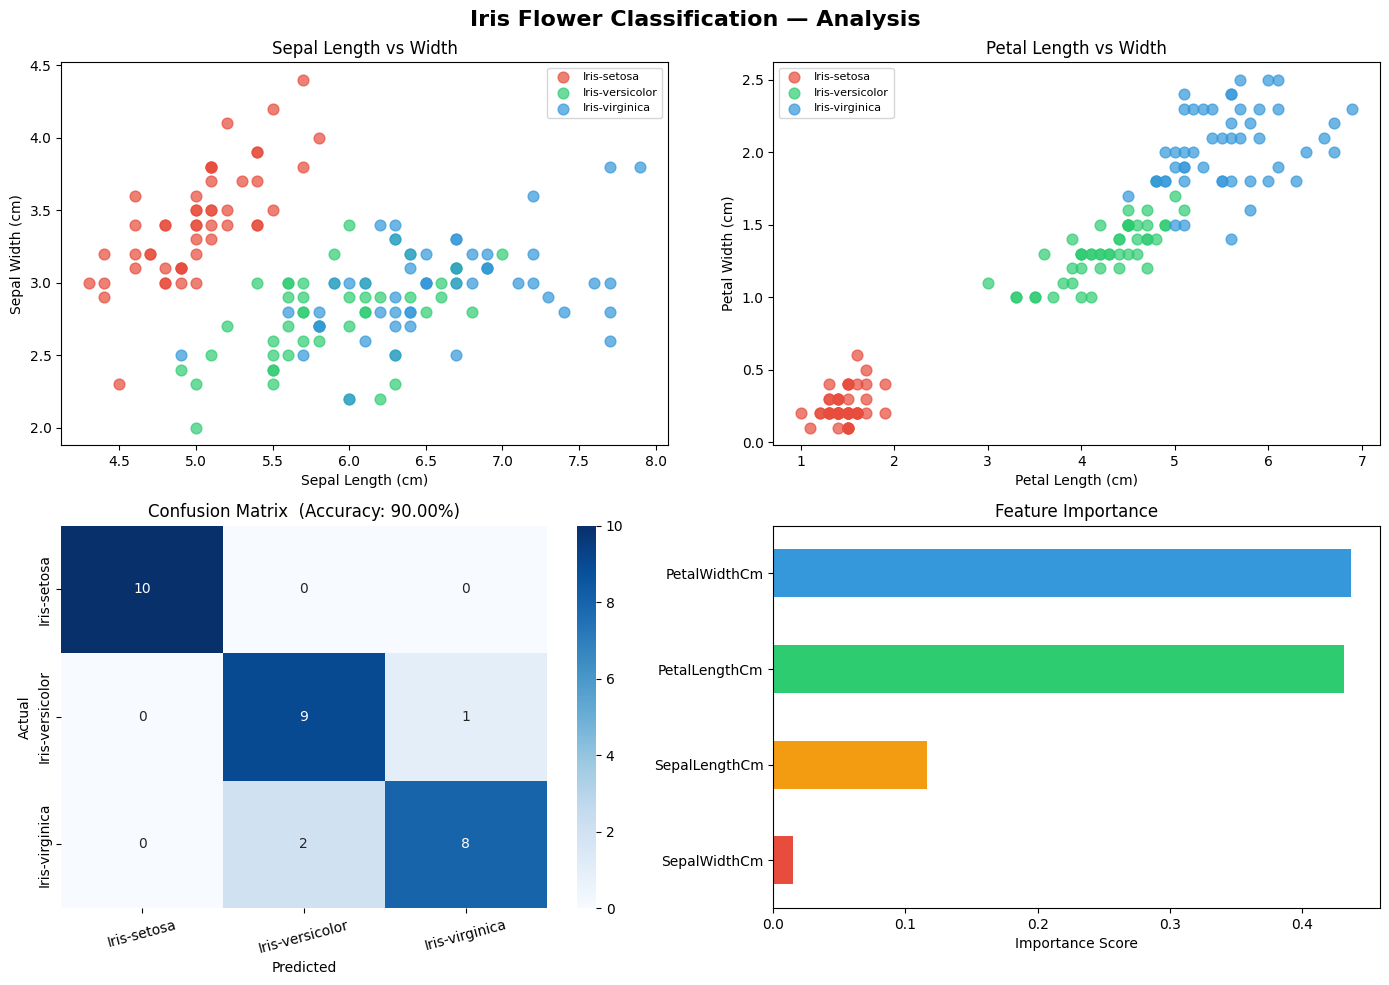


[Saved] iris_classification_results.png

--- Sample Prediction ---
Input  : SepalLen=5.1, SepalWid=3.5, PetalLen=1.4, PetalWid=0.2
Predicted Species : Iris-setosa

Task 1 Complete!


In [1]:
# ============================================================
# TASK 1: Iris Flower Classification
# CodeAlpha Data Science Internship
# Student: Zoha Yousaf | ID: CA/DF1/83644
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('Iris.csv')
print("=" * 55)
print("        IRIS FLOWER CLASSIFICATION")
print("=" * 55)
print(f"\nDataset Shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nClass distribution:\n{df['Species'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ── 2. PREPARE FEATURES ──────────────────────────────────────
# Drop the Id column (not a feature)
df = df.drop(columns=['Id'])

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── 3. TRAIN MODEL ───────────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── 4. EVALUATE ──────────────────────────────────────────────
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n{'=' * 55}")
print(f"  Model Accuracy : {acc * 100:.2f}%")
print(f"{'=' * 55}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=le.classes_))

# ── 5. VISUALISATIONS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Flower Classification — Analysis', fontsize=16, fontweight='bold')

colors = {'Iris-setosa': '#e74c3c',
          'Iris-versicolor': '#2ecc71',
          'Iris-virginica': '#3498db'}

# Plot 1 – Sepal scatter
ax = axes[0, 0]
for species, color in colors.items():
    mask = df['Species'] == species
    ax.scatter(df.loc[mask, 'SepalLengthCm'],
               df.loc[mask, 'SepalWidthCm'],
               label=species, color=color, alpha=0.7, s=60)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Sepal Length vs Width')
ax.legend(fontsize=8)

# Plot 2 – Petal scatter
ax = axes[0, 1]
for species, color in colors.items():
    mask = df['Species'] == species
    ax.scatter(df.loc[mask, 'PetalLengthCm'],
               df.loc[mask, 'PetalWidthCm'],
               label=species, color=color, alpha=0.7, s=60)
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Petal Length vs Width')
ax.legend(fontsize=8)

# Plot 3 – Confusion matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix  (Accuracy: {acc*100:.2f}%)')
ax.tick_params(axis='x', rotation=15)

# Plot 4 – Feature importance
ax = axes[1, 1]
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
ax.set_title('Feature Importance')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('iris_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] iris_classification_results.png")

# ── 6. SAMPLE PREDICTION ─────────────────────────────────────
print("\n--- Sample Prediction ---")
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
pred   = model.predict(sample)
print(f"Input  : SepalLen=5.1, SepalWid=3.5, PetalLen=1.4, PetalWid=0.2")
print(f"Predicted Species : {le.inverse_transform(pred)[0]}")
print("\nTask 1 Complete!")


       UNEMPLOYMENT ANALYSIS — INDIA (Covid-19 Impact)

[Dataset 1] Unemployment in India
  Shape   : (768, 7)
  Columns : ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  

[Dataset 2] Unemployment Rate upto Nov-2020
  Shape   : (267, 9)
  Columns : ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate 

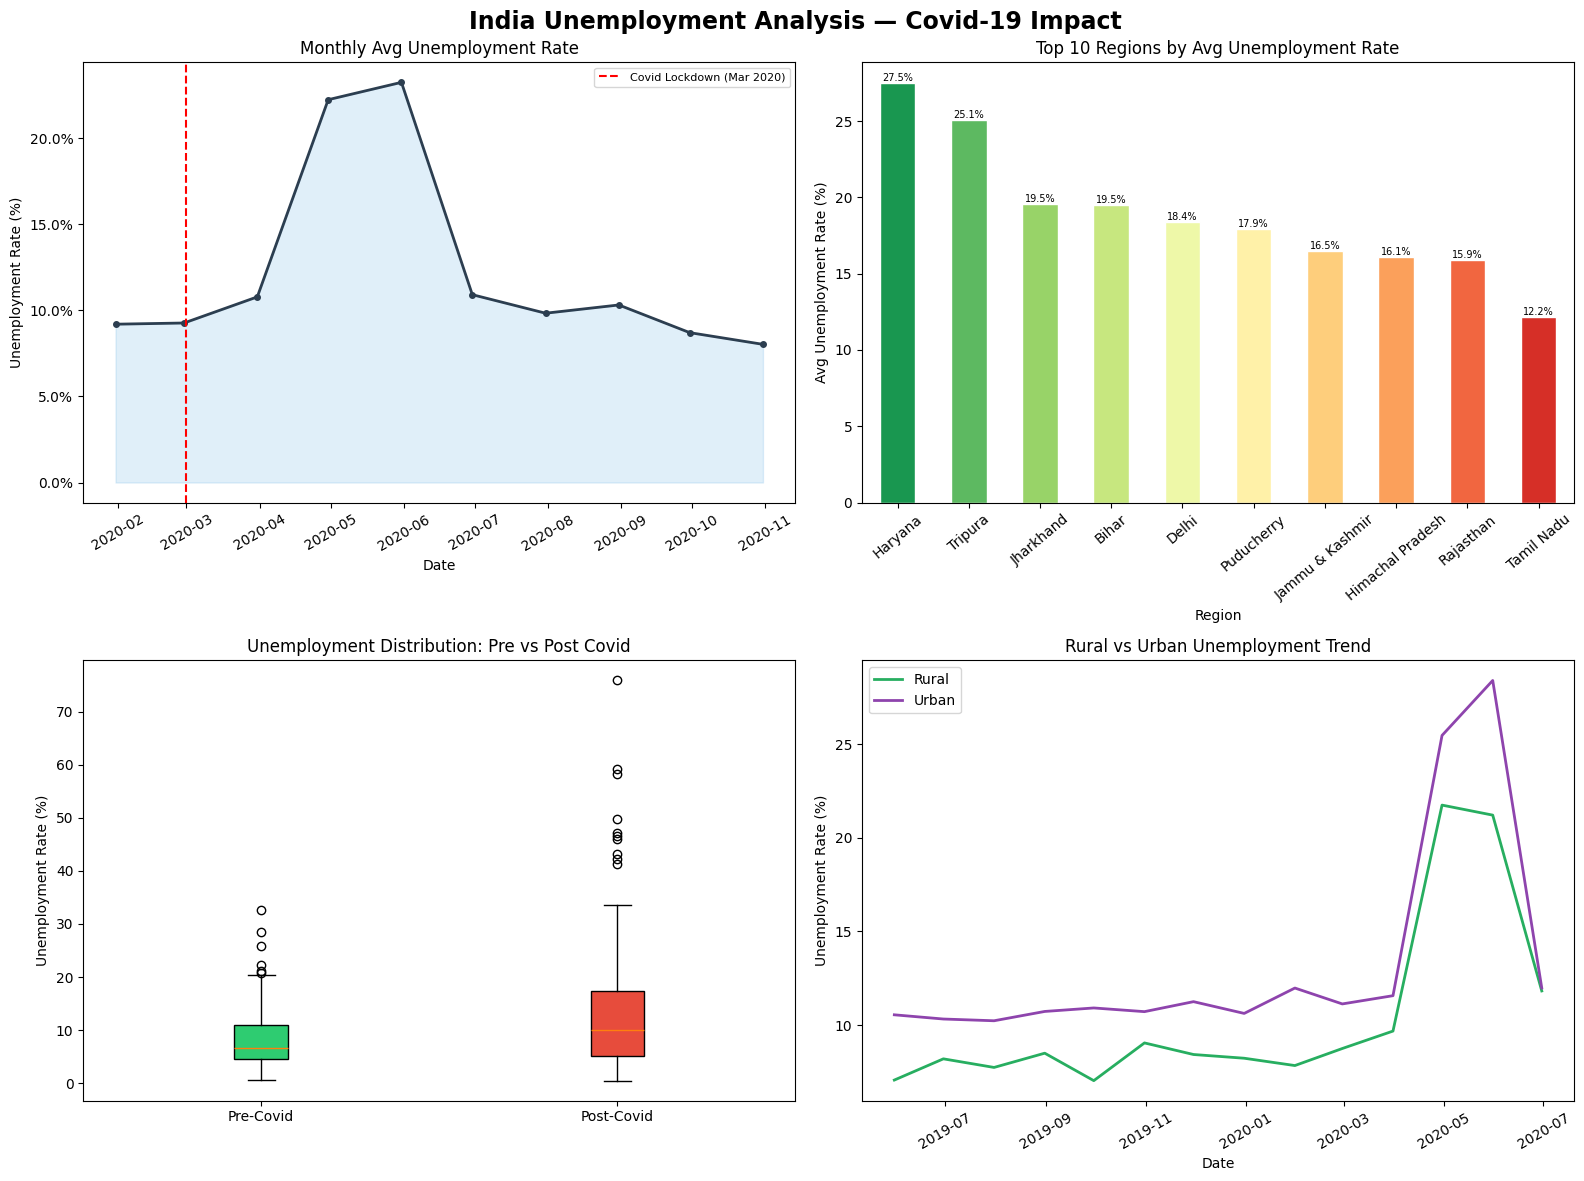


[Saved] unemployment_analysis_results.png

  KEY INSIGHTS
1. Pre-Covid average unemployment  : 9.23%
2. Post-Covid average unemployment : 13.01%
3. Increase due to Covid           : +3.78 percentage points
4. Highest spike month             : May 2020
5. Most affected region            : Haryana

Task 2 Complete!


In [3]:
# ============================================================
# TASK 2: Unemployment Analysis with Python
# CodeAlpha Data Science Internship
# Student: Zoha Yousaf | ID: CA/DF1/83644
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df1 = pd.read_csv('Unemployment_in_India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Clean column names (strip spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print("=" * 60)
print("       UNEMPLOYMENT ANALYSIS — INDIA (Covid-19 Impact)")
print("=" * 60)

print("\n[Dataset 1] Unemployment in India")
print(f"  Shape   : {df1.shape}")
print(f"  Columns : {list(df1.columns)}")
print(f"\n{df1.head(3)}")

print("\n[Dataset 2] Unemployment Rate upto Nov-2020")
print(f"  Shape   : {df2.shape}")
print(f"  Columns : {list(df2.columns)}")
print(f"\n{df2.head(3)}")

# ── 2. CLEAN & PREPARE ───────────────────────────────────────
# Dataset 2 has geo info → richer for time-series analysis
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True)
df2 = df2.sort_values('Date')

unemp_col  = 'Estimated Unemployment Rate (%)'
employ_col = 'Estimated Employed'

print(f"\nDate range: {df2['Date'].min().date()} → {df2['Date'].max().date()}")
print(f"Regions   : {df2['Region'].nunique()}")
print(f"\nMissing values:\n{df2[[unemp_col, employ_col]].isnull().sum()}")

# Monthly national average
monthly = df2.groupby('Date')[unemp_col].mean().reset_index()
monthly.columns = ['Date', 'Avg_Unemployment_Rate']

# ── 3. SUMMARY STATS ─────────────────────────────────────────
pre_covid  = monthly[monthly['Date'] < '2020-03-01']['Avg_Unemployment_Rate']
post_covid = monthly[monthly['Date'] >= '2020-03-01']['Avg_Unemployment_Rate']

print("\n--- Summary Statistics ---")
print(f"Pre-Covid  avg unemployment  : {pre_covid.mean():.2f}%")
print(f"Post-Covid avg unemployment  : {post_covid.mean():.2f}%")
print(f"Peak unemployment rate       : {monthly['Avg_Unemployment_Rate'].max():.2f}%  "
      f"({monthly.loc[monthly['Avg_Unemployment_Rate'].idxmax(), 'Date'].strftime('%b %Y')})")

# ── 4. VISUALISATIONS ────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('India Unemployment Analysis — Covid-19 Impact',
             fontsize=17, fontweight='bold', y=0.98)

# ── Plot 1: Monthly trend with Covid marker
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(monthly['Date'], monthly['Avg_Unemployment_Rate'],
         color='#2c3e50', linewidth=2, marker='o', markersize=4)
ax1.axvline(pd.Timestamp('2020-03-01'), color='red',
            linestyle='--', linewidth=1.5, label='Covid Lockdown (Mar 2020)')
ax1.fill_between(monthly['Date'], monthly['Avg_Unemployment_Rate'],
                 alpha=0.15, color='#3498db')
ax1.set_title('Monthly Avg Unemployment Rate')
ax1.set_xlabel('Date')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# ── Plot 2: Top 10 regions — highest avg unemployment
ax2 = fig.add_subplot(2, 2, 2)
region_avg = (df2.groupby('Region')[unemp_col]
              .mean()
              .sort_values(ascending=False)
              .head(10))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(region_avg)))
region_avg.plot(kind='bar', ax=ax2, color=colors_bar, edgecolor='white')
ax2.set_title('Top 10 Regions by Avg Unemployment Rate')
ax2.set_xlabel('Region')
ax2.set_ylabel('Avg Unemployment Rate (%)')
ax2.tick_params(axis='x', rotation=40)
for bar in ax2.patches:
    ax2.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', fontsize=7)

# ── Plot 3: Pre vs Post Covid comparison box
ax3 = fig.add_subplot(2, 2, 3)
df2['Period'] = df2['Date'].apply(
    lambda x: 'Post-Covid\n(Mar 2020+)' if x >= pd.Timestamp('2020-03-01')
    else 'Pre-Covid\n(Before Mar 2020)')
period_data = [
    df2[df2['Period'].str.startswith('Pre')][unemp_col].dropna(),
    df2[df2['Period'].str.startswith('Post')][unemp_col].dropna()
]
bp = ax3.boxplot(period_data, labels=['Pre-Covid', 'Post-Covid'],
                 patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax3.set_title('Unemployment Distribution: Pre vs Post Covid')
ax3.set_ylabel('Unemployment Rate (%)')

# ── Plot 4: Area-wise (Rural / Urban if in df1)
ax4 = fig.add_subplot(2, 2, 4)
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), dayfirst=True)
unemp_col1 = 'Estimated Unemployment Rate (%)'
if 'Area' in df1.columns:
    area_monthly = (df1.groupby(['Date', 'Area'])[unemp_col1]
                    .mean().reset_index())
    for area, color in zip(['Rural', 'Urban'], ['#27ae60', '#8e44ad']):
        sub = area_monthly[area_monthly['Area'] == area]
        if not sub.empty:
            ax4.plot(sub['Date'], sub[unemp_col1],
                     label=area, color=color, linewidth=2)
    ax4.set_title('Rural vs Urban Unemployment Trend')
    ax4.set_ylabel('Unemployment Rate (%)')
    ax4.set_xlabel('Date')
    ax4.legend()
    ax4.tick_params(axis='x', rotation=30)
else:
    ax4.text(0.5, 0.5, 'Area column not available', transform=ax4.transAxes,
             ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('unemployment_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] unemployment_analysis_results.png")

# ── 5. KEY INSIGHTS ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  KEY INSIGHTS")
print("=" * 60)
print(f"1. Pre-Covid average unemployment  : {pre_covid.mean():.2f}%")
print(f"2. Post-Covid average unemployment : {post_covid.mean():.2f}%")
increase = post_covid.mean() - pre_covid.mean()
print(f"3. Increase due to Covid           : +{increase:.2f} percentage points")
peak_month = monthly.loc[monthly['Avg_Unemployment_Rate'].idxmax(), 'Date']
print(f"4. Highest spike month             : {peak_month.strftime('%B %Y')}")
print(f"5. Most affected region            : {region_avg.idxmax()}")
print("\nTask 2 Complete!")


        CAR PRICE PREDICTION — ML REGRESSION

Dataset Shape : (301, 9)
Columns       : ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_

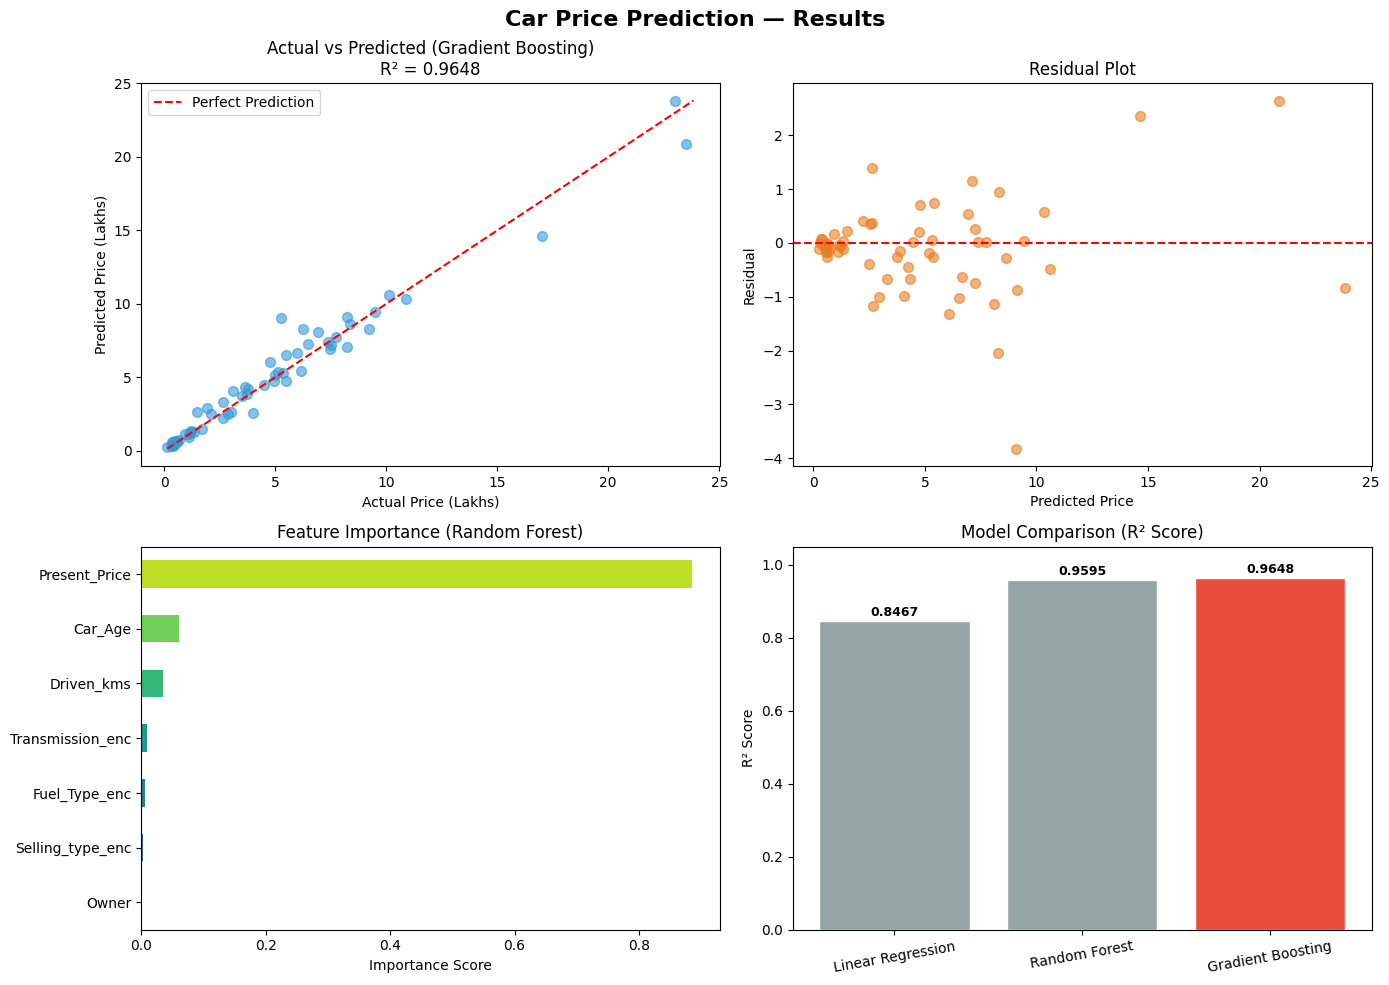


[Saved] car_price_prediction_results.png

--- Sample Prediction ---
Car   : 5-year-old Petrol, 40,000 km, Present Price 6L
Predicted Selling Price : ₹ 4.52 Lakhs

Task 3 Complete!


In [5]:
# ============================================================
# TASK 3: Car Price Prediction with Machine Learning
# CodeAlpha Data Science Internship
# Student: Zoha Yousaf | ID: CA/DF1/83644
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('car_data.csv')

print("=" * 58)
print("        CAR PRICE PREDICTION — ML REGRESSION")
print("=" * 58)
print(f"\nDataset Shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive stats:\n{df.describe()}")

# ── 2. FEATURE ENGINEERING ───────────────────────────────────
# Car Age from Year (dataset circa 2020)
df['Car_Age'] = 2020 - df['Year']

# Price Depreciation ratio
df['Price_Ratio'] = df['Selling_Price'] / df['Present_Price']

# Encode categorical columns
cat_cols = ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Feature matrix
feature_cols = ['Present_Price', 'Driven_kms', 'Car_Age',
                'Owner', 'Fuel_Type_enc', 'Selling_type_enc',
                'Transmission_enc']
X = df[feature_cols]
y = df['Selling_Price']

print(f"\nFeatures used : {feature_cols}")
print(f"\nTarget (Selling_Price) stats:")
print(f"  Min: {y.min():.2f}  Max: {y.max():.2f}  Mean: {y.mean():.2f}")

# ── 3. TRAIN / TEST SPLIT ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain samples : {len(X_train)}  |  Test samples : {len(X_test)}")

# ── 4. TRAIN MULTIPLE MODELS ─────────────────────────────────
models = {
    'Linear Regression'        : LinearRegression(),
    'Random Forest'            : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'        : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds        = mdl.predict(X_test)
    mae          = mean_absolute_error(y_test, preds)
    rmse         = np.sqrt(mean_squared_error(y_test, preds))
    r2           = r2_score(y_test, preds)
    results[name] = {'model': mdl, 'preds': preds, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n{name}")
    print(f"  MAE  : {mae:.4f} Lakhs")
    print(f"  RMSE : {rmse:.4f} Lakhs")
    print(f"  R²   : {r2:.4f}")

# Best model = highest R²
best_name  = max(results, key=lambda k: results[k]['R2'])
best       = results[best_name]
print(f"\n{'=' * 58}")
print(f"  Best Model : {best_name}  (R² = {best['R2']:.4f})")
print(f"{'=' * 58}")

# ── 5. VISUALISATIONS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Car Price Prediction — Results', fontsize=16, fontweight='bold')

# Plot 1 – Actual vs Predicted (best model)
ax = axes[0, 0]
ax.scatter(y_test, best['preds'], alpha=0.6, color='#3498db', s=50)
lims = [min(y_test.min(), best['preds'].min()),
        max(y_test.max(), best['preds'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Price (Lakhs)')
ax.set_ylabel('Predicted Price (Lakhs)')
ax.set_title(f'Actual vs Predicted ({best_name})\nR² = {best["R2"]:.4f}')
ax.legend()

# Plot 2 – Residuals
ax = axes[0, 1]
residuals = y_test.values - best['preds']
ax.scatter(best['preds'], residuals, alpha=0.6, color='#e67e22', s=50)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted Price')
ax.set_ylabel('Residual')
ax.set_title('Residual Plot')

# Plot 3 – Feature Importance (Random Forest)
ax = axes[1, 0]
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_fi)
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance Score')

# Plot 4 – Model comparison bar
ax = axes[1, 1]
model_names = list(results.keys())
r2_scores   = [results[n]['R2']  for n in model_names]
bar_colors  = ['#e74c3c' if n == best_name else '#95a5a6' for n in model_names]
bars = ax.bar(model_names, r2_scores, color=bar_colors, edgecolor='white')
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005, f'{score:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Model Comparison (R² Score)')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('car_price_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] car_price_prediction_results.png")

# ── 6. SAMPLE PREDICTION ─────────────────────────────────────
print("\n--- Sample Prediction ---")
sample_data = pd.DataFrame({
    'Present_Price'   : [6.0],
    'Driven_kms'      : [40000],
    'Car_Age'         : [5],
    'Owner'           : [0],
    'Fuel_Type_enc'   : [0],    # Petrol
    'Selling_type_enc': [0],    # Dealer
    'Transmission_enc': [0],    # Manual
})
pred_price = best['model'].predict(sample_data)[0]
print(f"Car   : 5-year-old Petrol, 40,000 km, Present Price 6L")
print(f"Predicted Selling Price : ₹ {pred_price:.2f} Lakhs")
print("\nTask 3 Complete!")


          SALES PREDICTION — ADVERTISING SPEND

Dataset Shape : (200, 4)
Columns       : ['TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Descriptive stats:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

--- Correlation with Sales ---
Sales        1.000000
TV  

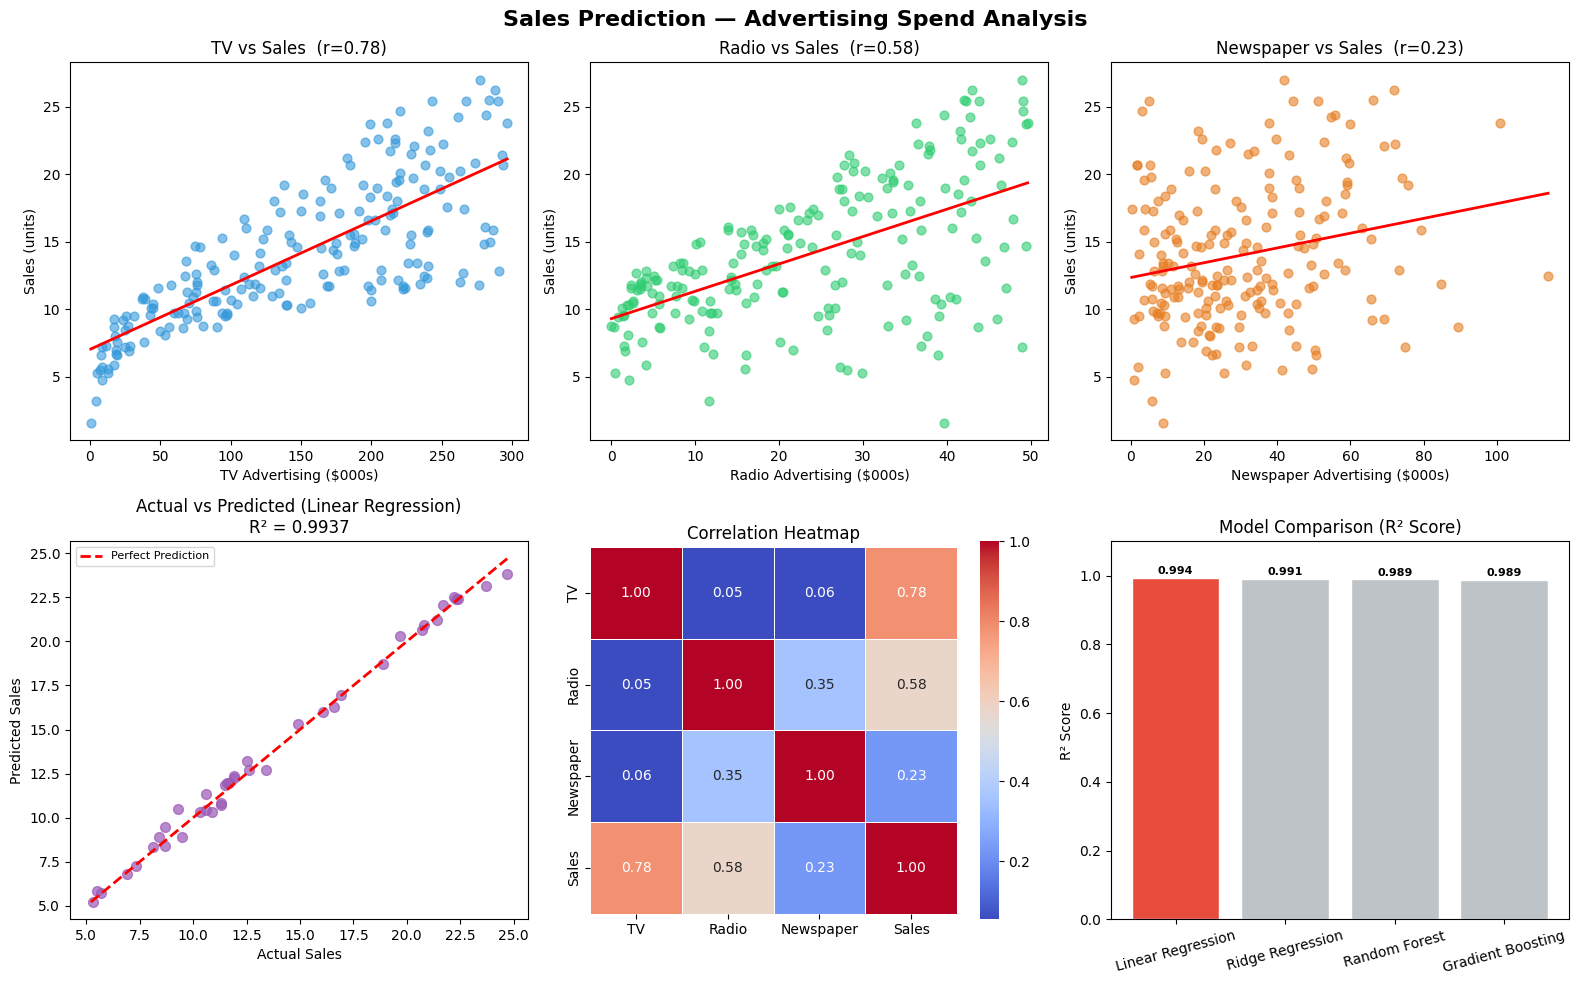


[Saved] sales_prediction_results.png

  BUSINESS INSIGHTS
1. TV Advertising correlation with Sales     : 0.782  ← HIGHEST
2. Radio Advertising correlation with Sales  : 0.576
3. Newspaper correlation with Sales          : 0.228  ← LOWEST
4. Best model R²                             : 0.9937

→ RECOMMENDATION: Invest primarily in TV advertising for maximum
  sales impact. Radio provides a moderate boost.
  Newspaper has the weakest effect on sales.

--- Sample Prediction ---
Budget: TV=$150K  Radio=$30K  Newspaper=$20K
Predicted Sales : 15.90 units

Task 4 Complete!


In [6]:
# ============================================================
# TASK 4: Sales Prediction using Python
# CodeAlpha Data Science Internship
# Student: Zoha Yousaf | ID: CA/DF1/83644
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('Advertising.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("=" * 58)
print("          SALES PREDICTION — ADVERTISING SPEND")
print("=" * 58)
print(f"\nDataset Shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nDescriptive stats:\n{df.describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ── 2. EXPLORATORY DATA ANALYSIS ────────────────────────────
print("\n--- Correlation with Sales ---")
print(df.corr()['Sales'].sort_values(ascending=False))

# ── 3. FEATURE ENGINEERING ──────────────────────────────────
# Total advertising budget
df['Total_Ad_Spend']   = df['TV'] + df['Radio'] + df['Newspaper']
# TV share of budget
df['TV_Share']         = df['TV'] / df['Total_Ad_Spend']
# TV × Radio interaction (historically high correlators)
df['TV_Radio_Interact']= df['TV'] * df['Radio']

features = ['TV', 'Radio', 'Newspaper',
            'Total_Ad_Spend', 'TV_Share', 'TV_Radio_Interact']
X = df[features]
y = df['Sales']

print(f"\nFeatures used : {features}")
print(f"\nTarget (Sales) stats:  Min={y.min():.2f}  Max={y.max():.2f}  Mean={y.mean():.2f}")

# ── 4. TRAIN / TEST SPLIT ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain : {len(X_train)} samples  |  Test : {len(X_test)} samples")

# ── 5. TRAIN MODELS ──────────────────────────────────────────
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n--- Model Results ---")
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    preds         = mdl.predict(X_test)
    mae           = mean_absolute_error(y_test, preds)
    rmse          = np.sqrt(mean_squared_error(y_test, preds))
    r2            = r2_score(y_test, preds)
    cv_scores     = cross_val_score(mdl, X, y, cv=5, scoring='r2')
    results[name] = {'model': mdl, 'preds': preds,
                     'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv_scores.mean()}
    print(f"\n{name}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  CV R²   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

best_name = max(results, key=lambda k: results[k]['R2'])
best      = results[best_name]
print(f"\n{'=' * 58}")
print(f"  Best Model : {best_name}  (R² = {best['R2']:.4f})")
print(f"{'=' * 58}")

# ── 6. VISUALISATIONS ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Sales Prediction — Advertising Spend Analysis',
             fontsize=16, fontweight='bold')

# Plot 1 – TV vs Sales
ax = axes[0, 0]
ax.scatter(df['TV'], df['Sales'], alpha=0.6, color='#3498db', s=40)
m, b = np.polyfit(df['TV'], df['Sales'], 1)
x_line = np.linspace(df['TV'].min(), df['TV'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
ax.set_xlabel('TV Advertising ($000s)')
ax.set_ylabel('Sales (units)')
ax.set_title(f'TV vs Sales  (r={df["TV"].corr(df["Sales"]):.2f})')

# Plot 2 – Radio vs Sales
ax = axes[0, 1]
ax.scatter(df['Radio'], df['Sales'], alpha=0.6, color='#2ecc71', s=40)
m, b = np.polyfit(df['Radio'], df['Sales'], 1)
x_line = np.linspace(df['Radio'].min(), df['Radio'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
ax.set_xlabel('Radio Advertising ($000s)')
ax.set_ylabel('Sales (units)')
ax.set_title(f'Radio vs Sales  (r={df["Radio"].corr(df["Sales"]):.2f})')

# Plot 3 – Newspaper vs Sales
ax = axes[0, 2]
ax.scatter(df['Newspaper'], df['Sales'], alpha=0.6, color='#e67e22', s=40)
m, b = np.polyfit(df['Newspaper'], df['Sales'], 1)
x_line = np.linspace(df['Newspaper'].min(), df['Newspaper'].max(), 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
ax.set_xlabel('Newspaper Advertising ($000s)')
ax.set_ylabel('Sales (units)')
ax.set_title(f'Newspaper vs Sales  (r={df["Newspaper"].corr(df["Sales"]):.2f})')

# Plot 4 – Actual vs Predicted (best model)
ax = axes[1, 0]
ax.scatter(y_test, best['preds'], alpha=0.7, color='#9b59b6', s=50)
lims = [min(y_test.min(), best['preds'].min()),
        max(y_test.max(), best['preds'].max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'Actual vs Predicted ({best_name})\nR² = {best["R2"]:.4f}')
ax.legend(fontsize=8)

# Plot 5 – Correlation heatmap
ax = axes[1, 1]
corr = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap')

# Plot 6 – Model R² comparison
ax = axes[1, 2]
names_list  = list(results.keys())
r2_list     = [results[n]['R2'] for n in names_list]
bar_colors  = ['#e74c3c' if n == best_name else '#bdc3c7' for n in names_list]
bars = ax.bar(names_list, r2_list, color=bar_colors, edgecolor='white')
for bar, score in zip(bars, r2_list):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005, f'{score:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Model Comparison (R² Score)')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('sales_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] sales_prediction_results.png")

# ── 7. BUSINESS INSIGHTS ────────────────────────────────────
print("\n" + "=" * 58)
print("  BUSINESS INSIGHTS")
print("=" * 58)
tv_corr   = df['TV'].corr(df['Sales'])
rad_corr  = df['Radio'].corr(df['Sales'])
news_corr = df['Newspaper'].corr(df['Sales'])
print(f"1. TV Advertising correlation with Sales     : {tv_corr:.3f}  ← HIGHEST")
print(f"2. Radio Advertising correlation with Sales  : {rad_corr:.3f}")
print(f"3. Newspaper correlation with Sales          : {news_corr:.3f}  ← LOWEST")
print(f"4. Best model R²                             : {best['R2']:.4f}")
print(f"\n→ RECOMMENDATION: Invest primarily in TV advertising for maximum")
print(f"  sales impact. Radio provides a moderate boost.")
print(f"  Newspaper has the weakest effect on sales.")

# ── 8. SAMPLE PREDICTION ────────────────────────────────────
print("\n--- Sample Prediction ---")
sample = pd.DataFrame({
    'TV': [150], 'Radio': [30], 'Newspaper': [20],
    'Total_Ad_Spend': [200], 'TV_Share': [0.75],
    'TV_Radio_Interact': [4500]
})
pred_sales = best['model'].predict(sample)[0]
print(f"Budget: TV=$150K  Radio=$30K  Newspaper=$20K")
print(f"Predicted Sales : {pred_sales:.2f} units")
print("\nTask 4 Complete!")
